# WLASL Sign Language Recognition with CNN-Mamba

This notebook implements a **MobileNetV3-Large + Selective State Space Model (Mamba)** architecture for real-time word-level American Sign Language (ASL) recognition on the WLASL dataset.

**Architecture:**
- **Spatial Encoder:** MobileNetV3-Large (ImageNet pretrained)
- **Temporal Decoder:** 2-layer selective SSM (Mamba)
- **Input:** 25 frames × 224 × 224 RGB (1 second at 25 fps)
- **Output:** 300 ASL gloss classes (WLASL300 subset)

**Key Properties:**
- Linear-time temporal complexity: O(n)
- Fixed memory state during inference (no KV cache growth)
- ~6M parameters, suitable for edge deployment

## 1. Setup and Imports

In [1]:
# Install required packages (run once)
!pip install -q opencv-python scikit-learn seaborn

import os
import sys
import json
import time
import random
import gc
import numpy as np
import pandas as pd
import cv2
import psutil
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, classification_report

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import mobilenet_v3_large

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


## 2. Configuration

Dataset paths use a dual-source fallback system: primary videos from `wlasl-processed` with automatic fallback to `wlasl2000-resized` for missing files.

In [2]:
# Configuration
class Config:
    # Dataset
    NUM_CLASSES = 300          # WLASL300 (or 100, 1000, 2000)
    NUM_FRAMES = 16            # Frames per video (1 second at 25 fps)
    FRAME_SIZE = 224           # Spatial resolution
    
    # Model
    D_MODEL = 256              # Mamba hidden dimension
    D_STATE = 16               # SSM state dimension
    N_MAMBA_LAYERS = 2         # Number of Mamba blocks
    DROPOUT = 0.5
    
    # Training
    BATCH_SIZE = 16
    NUM_EPOCHS = 100
    LEARNING_RATE = 1e-3
    WEIGHT_DECAY = 1e-4
    PATIENCE = 10              # Early stopping patience
    
    # Paths (Kaggle dual dataset fallback)
    JSON_PATH = '/kaggle/input/datasets/risangbaskoro/wlasl-processed/WLASL_v0.3.json'
    VIDEO_ROOT = '/kaggle/input/datasets/risangbaskoro/wlasl-processed/videos'
    VIDEO_ROOT_BACKUP = '/kaggle/input/datasets/sttaseen/wlasl2000-resized/wlasl-complete/videos'
    CHECKPOINT_DIR = './checkpoints'
    
    # Reproducibility
    SEED = 42

# Create checkpoint directory
os.makedirs(Config.CHECKPOINT_DIR, exist_ok=True)

# Set random seeds
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(Config.SEED)
print("Configuration loaded successfully!")

Configuration loaded successfully!


## 3. Data Exploration

Total glosses in full dataset: 2000

WLASL300 Statistics:
  Total videos: 5117
  Train: 3549 (69.4%)
  Val: 900 (17.6%)
  Test: 668 (13.1%)
  Classes: 300
  Instances per class: min=14, max=40, mean=17.1


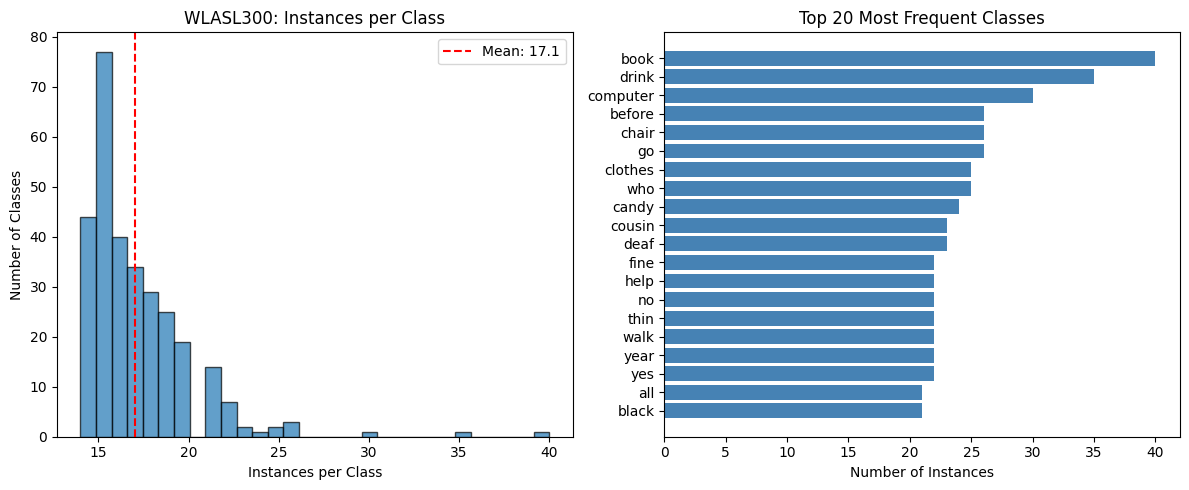


Class distribution plot saved!


In [3]:
# Load WLASL annotations
def load_wlasl_data(json_path):
    with open(json_path, 'r') as f:
        data = json.load(f)
    return data

data = load_wlasl_data(Config.JSON_PATH)
print(f"Total glosses in full dataset: {len(data)}")

# Get statistics for top-k classes
def analyze_subset(data, k=300):
    gloss_counts = [(entry['gloss'], len(entry['instances'])) for entry in data]
    gloss_counts.sort(key=lambda x: x[1], reverse=True)
    top_k = gloss_counts[:k]
    
    # Statistics
    subset_stats = {'train': 0, 'val': 0, 'test': 0}
    counts = []
    
    for gloss, _ in top_k:
        entry = next(e for e in data if e['gloss'] == gloss)
        class_count = {'train': 0, 'val': 0, 'test': 0, 'total': 0}
        for inst in entry['instances']:
            split = inst['split']
            subset_stats[split] += 1
            class_count[split] += 1
            class_count['total'] += 1
        counts.append(class_count['total'])
    
    total = sum(subset_stats.values())
    print(f"\nWLASL{k} Statistics:")
    print(f"  Total videos: {total}")
    print(f"  Train: {subset_stats['train']} ({subset_stats['train']/total*100:.1f}%)")
    print(f"  Val: {subset_stats['val']} ({subset_stats['val']/total*100:.1f}%)")
    print(f"  Test: {subset_stats['test']} ({subset_stats['test']/total*100:.1f}%)")
    print(f"  Classes: {k}")
    print(f"  Instances per class: min={min(counts)}, max={max(counts)}, mean={np.mean(counts):.1f}")
    
    return top_k

top_300 = analyze_subset(data, k=Config.NUM_CLASSES)

# Visualize class distribution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
counts = [c[1] for c in top_300]
plt.hist(counts, bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Instances per Class')
plt.ylabel('Number of Classes')
plt.title('WLASL300: Instances per Class')
plt.axvline(np.mean(counts), color='red', linestyle='--', label=f'Mean: {np.mean(counts):.1f}')
plt.legend()

plt.subplot(1, 2, 2)
names = [c[0] for c in top_300[:20]]
values = [c[1] for c in top_300[:20]]
plt.barh(range(len(names)), values, color='steelblue')
plt.yticks(range(len(names)), names)
plt.xlabel('Number of Instances')
plt.title('Top 20 Most Frequent Classes')
plt.gca().invert_yaxis()

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nClass distribution plot saved!")

## 4. Data Loading

In [4]:
# ============================================================
# PREPROCESSING: Extract video frames to uint8 .npy files
# ============================================================
# Run this ONCE before training to eliminate cv2/ffmpeg memory leaks.
# Frames are saved as uint8 numpy arrays (not float32) to save disk space.
# Size: 16x224x224x3 = ~2.4 MB per video (vs 9.6 MB in float32)
# Total: ~12 GB for 5000 videos, fits in Kaggle's 20 GB.

import os
import json
import gc
import cv2
import numpy as np
import torch
import psutil

FRAMES_ROOT = '/kaggle/working/frames_npy'
MANIFEST_PATH = '/kaggle/working/frames_manifest.json'
os.makedirs(FRAMES_ROOT, exist_ok=True)


def extract_frames_from_video(video_path, num_frames=16, frame_size=224, max_retries=3):
    """Extract frames from video and return as uint8 numpy array (T, H, W, 3)."""
    for attempt in range(max_retries):
        cap = cv2.VideoCapture(video_path)
        if not cap.isOpened():
            cap.release()
            return None

        try:
            total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
            if total_frames <= 0:
                return None

            # Calculate target indices for uniform sampling
            target_indices = set(np.linspace(0, total_frames - 1, num_frames, dtype=int))

            frames = []
            frame_idx = 0

            # Read frames SEQUENTIALLY (no seeking to avoid FFmpeg memory leaks)
            while len(frames) < num_frames:
                ret, frame = cap.read()
                if not ret:
                    break

                if frame_idx in target_indices:
                    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                    frame = cv2.resize(frame, (frame_size, frame_size))
                    frames.append(frame)  # Keep as uint8, don't divide by 255

                frame_idx += 1

            if len(frames) == 0:
                return None

            # Pad if we got fewer frames than expected
            while len(frames) < num_frames:
                frames.append(frames[-1])

            # Stack as (T, H, W, 3) uint8
            frames = np.stack(frames).astype(np.uint8)
            return frames

        finally:
            cap.release()
            gc.collect()


def preprocess_dataset(json_path, video_root, video_root_backup, num_classes,
                       num_frames, frame_size, splits):
    """Preprocess all videos and save frames as .npy files."""
    process = psutil.Process(os.getpid())

    with open(json_path, 'r') as f:
        data = json.load(f)

    # Select top-k classes
    gloss_counts = [(entry['gloss'], len(entry['instances'])) for entry in data]
    gloss_counts.sort(key=lambda x: x[1], reverse=True)
    top_k_glosses = [g[0] for g in gloss_counts[:num_classes]]
    gloss_to_label = {gloss: idx for idx, gloss in enumerate(top_k_glosses)}

    # Count total videos
    total_videos = 0
    for entry in data:
        if entry['gloss'] not in gloss_to_label:
            continue
        for inst in entry['instances']:
            if inst['split'] in splits:
                total_videos += 1

    print(f"Total videos to process: {total_videos}")
    print(f"Output directory: {FRAMES_ROOT}")

    manifest = {
        'metadata': {
            'num_frames': num_frames,
            'frame_size': frame_size
        },
        'videos': {}
    }

    processed = 0
    failed = 0

    for entry in data:
        if entry['gloss'] not in gloss_to_label:
            continue

        for inst in entry['instances']:
            inst_split = inst['split']
            if inst_split not in splits:
                continue

            video_id = inst['video_id']
            video_path = os.path.join(video_root, f"{video_id}.mp4")

            if not os.path.exists(video_path) and video_root_backup is not None:
                video_path = os.path.join(video_root_backup, f"{video_id}.mp4")

            if not os.path.exists(video_path):
                continue

            npy_path = os.path.join(FRAMES_ROOT, f"{video_id}.npy")

            # Skip if already processed
            if os.path.exists(npy_path):
                manifest['videos'][video_id] = {
                    'npy_path': npy_path,
                    'gloss': entry['gloss'],
                    'split': inst_split,
                    'label': gloss_to_label[entry['gloss']]
                }
                processed += 1
                continue

            frames = extract_frames_from_video(video_path, num_frames, frame_size)

            if frames is not None:
                np.save(npy_path, frames)
                manifest['videos'][video_id] = {
                    'npy_path': npy_path,
                    'gloss': entry['gloss'],
                    'split': inst_split,
                    'label': gloss_to_label[entry['gloss']]
                }
                processed += 1
            else:
                failed += 1

            if (processed + failed) % 500 == 0:
                print(f"  Processed: {processed}, Failed: {failed}, "
                      f"RAM: {process.memory_info().rss / (1024**2):.1f} MB")

    # Save manifest
    with open(MANIFEST_PATH, 'w') as f:
        json.dump(manifest, f)

    print(f"\nPreprocessing complete!")
    print(f"  Successfully processed: {processed}")
    print(f"  Failed: {failed}")
    print(f"  Manifest saved to: {MANIFEST_PATH}")

    # Print disk usage
    try:
        total_size = sum(os.path.getsize(os.path.join(FRAMES_ROOT, f)) 
                        for f in os.listdir(FRAMES_ROOT) if f.endswith('.npy'))
        print(f"  Total disk usage: {total_size / (1024**3):.2f} GB")
    except:
        pass


# Run preprocessing for all splits
preprocess_dataset(
    json_path=Config.JSON_PATH,
    video_root=Config.VIDEO_ROOT,
    video_root_backup=Config.VIDEO_ROOT_BACKUP,
    num_classes=Config.NUM_CLASSES,
    num_frames=Config.NUM_FRAMES,
    frame_size=Config.FRAME_SIZE,
    splits=['train', 'val', 'test']
)

gc.collect()
print("\nPreprocessing done! You can now run the training cells.")


Total videos to process: 5117
Output directory: /kaggle/working/frames_npy
  Processed: 500, Failed: 0, RAM: 987.6 MB
  Processed: 1000, Failed: 0, RAM: 1005.4 MB
  Processed: 1500, Failed: 0, RAM: 992.5 MB
  Processed: 2000, Failed: 0, RAM: 1006.9 MB
  Processed: 2500, Failed: 0, RAM: 990.4 MB


[h264 @ 0x48097380] Invalid NAL unit size (745 > 472).
[h264 @ 0x48097380] Error splitting the input into NAL units.
[mov,mp4,m4a,3gp,3g2,mj2 @ 0x48022900] stream 1, offset 0x3b468: partial file
[mov,mp4,m4a,3gp,3g2,mj2 @ 0x48022900] stream 1, offset 0x3b7d3: partial file


  Processed: 3000, Failed: 0, RAM: 1002.9 MB
  Processed: 3500, Failed: 0, RAM: 990.6 MB
  Processed: 4000, Failed: 0, RAM: 992.9 MB
  Processed: 4500, Failed: 0, RAM: 994.6 MB


[h264 @ 0x48498180] Invalid NAL unit size (71678 > 10776).
[h264 @ 0x48498180] missing picture in access unit with size 10780
[h264 @ 0x48105ac0] Invalid NAL unit size (71678 > 10776).
[h264 @ 0x48105ac0] Error splitting the input into NAL units.
[mov,mp4,m4a,3gp,3g2,mj2 @ 0x48022900] stream 1, offset 0x2a27a7: partial file


  Processed: 5000, Failed: 0, RAM: 990.9 MB

Preprocessing complete!
  Successfully processed: 5117
  Failed: 0
  Manifest saved to: /kaggle/working/frames_manifest.json
  Total disk usage: 11.48 GB

Preprocessing done! You can now run the training cells.


In [5]:
# ============================================================
# Dataset loading from preprocessed .npy uint8 files
# ============================================================
# No cv2/ffmpeg used - eliminates all memory leaks during training

class WLASLDatasetPreprocessed(Dataset):
    """WLASL Dataset loading from preprocessed uint8 .npy files.
    Frames are stored as (T, H, W, 3) uint8, converted to float32 here."""

    def __init__(self, manifest_path, split='train', transform=None):
        self.split = split
        self.transform = transform

        with open(manifest_path, 'r') as f:
            self.manifest = json.load(f)

        self.num_frames = self.manifest['metadata']['num_frames']
        self.frame_size = self.manifest['metadata']['frame_size']

        self.samples = []
        for video_id, info in self.manifest['videos'].items():
            # Train split includes both 'train' and 'val' instances
            if info['split'] == split:
                self.samples.append({
                    'video_id': video_id,
                    'npy_path': info['npy_path'],
                    'label': info['label'],
                    'gloss': info['gloss']
                })

        print(f"WLASL {split}: {len(self.samples)} samples loaded")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        # mmap_mode='r' mapea el archivo uint8 sin copiarlo a RAM
        frames = np.load(sample['npy_path'], mmap_mode='r')
        # torch.from_numpy comparte memoria con el mmap (sin copia)
        frames = torch.from_numpy(frames)
        # Permute + float + normalize: una sola conversión a float32
        frames = frames.permute(3, 0, 1, 2).float() / 255.0
        if self.transform:
            frames = self.transform(frames)
        return frames, sample['label'], sample['video_id']


class RandomHorizontalFlipVideo:
    def __init__(self, p=0.5):
        self.p = p

    def __call__(self, frames):
        if random.random() < self.p:
            frames = torch.flip(frames, dims=[3])
        return frames


class NormalizeVideo:
    def __init__(self, mean, std):
        self.mean = torch.tensor(mean).view(3, 1, 1, 1)
        self.std = torch.tensor(std).view(3, 1, 1, 1)

    def __call__(self, frames):
        return (frames - self.mean) / self.std


def get_data_loaders(manifest_path, num_classes=300, batch_size=32, num_workers=0,
                     pin_memory_train=False, pin_memory_eval=False,
                     include_train_val=True, include_test=True):
    """Create DataLoaders from preprocessed manifest."""
    train_transform = transforms.Compose([
        RandomHorizontalFlipVideo(p=0.5),
        NormalizeVideo(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    val_transform = transforms.Compose([
        NormalizeVideo(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    loaders = {}

    if include_train_val:
        train_dataset = WLASLDatasetPreprocessed(
            manifest_path=manifest_path,
            split='train',
            transform=train_transform
        )
        val_dataset = WLASLDatasetPreprocessed(
            manifest_path=manifest_path,
            split='val',
            transform=val_transform
        )

        train_loader = DataLoader(
            train_dataset, batch_size=batch_size, shuffle=True,
            num_workers=num_workers, pin_memory=pin_memory_train, drop_last=True
        )
        val_loader = DataLoader(
            val_dataset, batch_size=batch_size, shuffle=False,
            num_workers=num_workers, pin_memory=pin_memory_eval
        )
        loaders['train'] = train_loader
        loaders['val'] = val_loader

    if include_test:
        test_dataset = WLASLDatasetPreprocessed(
            manifest_path=manifest_path,
            split='test',
            transform=val_transform
        )
        test_loader = DataLoader(
            test_dataset, batch_size=batch_size, shuffle=False,
            num_workers=num_workers, pin_memory=pin_memory_eval
        )
        loaders['test'] = test_loader

    print("\nData loaders created (from preprocessed .npy files):")
    if 'train' in loaders:
        print(f"  Train batches: {len(loaders['train'])}")
    if 'val' in loaders:
        print(f"  Val batches: {len(loaders['val'])}")
    if 'test' in loaders:
        print(f"  Test batches: {len(loaders['test'])}")

    return loaders


# Create data loaders from preprocessed frames
MANIFEST_PATH = '/kaggle/working/frames_manifest.json'

loaders = get_data_loaders(
    manifest_path=MANIFEST_PATH,
    num_classes=Config.NUM_CLASSES,
    batch_size=Config.BATCH_SIZE,
    num_workers=0,
    pin_memory_train=False,
    pin_memory_eval=False,
    include_test=False
)

train_loader = loaders['train']
val_loader = loaders['val']


WLASL train: 3549 samples loaded
WLASL val: 900 samples loaded

Data loaders created (from preprocessed .npy files):
  Train batches: 221
  Val batches: 57


## 5. Model Definition

In [6]:
class SelectiveSSM(nn.Module):
    """Simplified Selective State Space Model (Mamba) in pure PyTorch."""
    
    def __init__(self, d_model, d_state=16, d_conv=4, expand=2):
        super().__init__()
        self.d_model = d_model
        self.d_state = d_state
        self.d_conv = d_conv
        self.expand = expand
        self.d_inner = int(self.expand * self.d_model)
        
        self.in_proj = nn.Linear(d_model, self.d_inner * 2, bias=False)
        
        self.conv1d = nn.Conv1d(
            in_channels=self.d_inner, out_channels=self.d_inner,
            kernel_size=d_conv, padding=d_conv - 1,
            groups=self.d_inner, bias=True
        )
        
        self.x_proj = nn.Linear(self.d_inner, d_state * 2 + 1, bias=False)
        self.dt_proj = nn.Linear(1, self.d_inner, bias=True)
        
        A = torch.arange(1, d_state + 1, dtype=torch.float32).repeat(self.d_inner, 1)
        self.A_log = nn.Parameter(torch.log(A))
        self.D = nn.Parameter(torch.ones(self.d_inner))
        
        self.out_proj = nn.Linear(self.d_inner, d_model, bias=False)
    
    def forward(self, x):
        B, L, D = x.shape
        
        x_and_res = self.in_proj(x)
        x_ssm, res = x_and_res.split([self.d_inner, self.d_inner], dim=-1)
        
        x_conv = self.conv1d(x_ssm.transpose(1, 2))[:, :, :L]
        x_conv = x_conv.transpose(1, 2)
        x_conv = F.silu(x_conv)
        
        y = self.ssm(x_conv)
        y = y * F.silu(res)
        
        return self.out_proj(y)
    
    def ssm(self, x):
        B, L, _ = x.shape
        
        x_dbl = self.x_proj(x)
        delta, B_ssm, C = x_dbl.split([1, self.d_state, self.d_state], dim=-1)
        
        delta = F.softplus(self.dt_proj(delta))
        A = -torch.exp(self.A_log.float())
        
        return self.selective_scan(x, delta, A, B_ssm, C)
    
    def selective_scan(self, x, delta, A, B, C):
        batch_size, L, d_in = x.shape
        d_state = A.size(1)
        
        # Precompute A_bar: (batch, L, d_in, d_state)
        # delta: (batch, L, 1) * A: (d_in, d_state)
        A_bar = torch.exp(delta.unsqueeze(-1) * A.unsqueeze(0).unsqueeze(0))
        
        # Precompute B_bar: (batch, L, d_in, d_state)
        B_bar = delta.unsqueeze(-1) * B.unsqueeze(2)
        
        # Precompute x_expanded: (batch, L, d_in, 1)
        x_expanded = x.unsqueeze(-1)
        
        # Initialize hidden state
        h = torch.zeros(batch_size, d_in, d_state, device=x.device, dtype=x.dtype)
        
        y_list = []
        for t in range(L):
            h = A_bar[:, t] * h + B_bar[:, t] * x_expanded[:, t]
            y_list.append((C[:, t].unsqueeze(1) * h).sum(dim=-1))
        
        y = torch.stack(y_list, dim=1)
        y = y + x * self.D.unsqueeze(0).unsqueeze(0)
        return y


class MambaBlock(nn.Module):
    def __init__(self, d_model, d_state=16, d_conv=4, expand=2, dropout=0.1):
        super().__init__()
        self.norm = nn.LayerNorm(d_model)
        self.mixer = SelectiveSSM(d_model, d_state, d_conv, expand)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x):
        residual = x
        x = self.norm(x)
        x = self.mixer(x)
        x = self.dropout(x)
        return x + residual


class MobileNetV3_Mamba(nn.Module):
    """CNN-Mamba hybrid for sign language recognition."""
    
    def __init__(self, num_classes=300, d_model=256, n_mamba_layers=2,
                 d_state=16, dropout=0.5, pretrained=True):
        super().__init__()
        
        # Spatial encoder
        mobilenet = mobilenet_v3_large(pretrained=pretrained)
        self.spatial_encoder = nn.Sequential(*list(mobilenet.features.children()))
        self.spatial_pool = nn.AdaptiveAvgPool2d(1)
        self.spatial_dim = 960
        
        # Projection
        self.input_proj = nn.Linear(self.spatial_dim, d_model)
        
        # Temporal decoder
        self.temporal_decoder = nn.ModuleList([
            MambaBlock(d_model, d_state=d_state, dropout=dropout)
            for _ in range(n_mamba_layers)
        ])
        
        # Classification head
        self.temporal_pool = nn.AdaptiveAvgPool1d(1)
        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Dropout(dropout),
            nn.Linear(d_model, num_classes),
        )
        
        self._init_weights()
    
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
    
    def extract_frame_features(self, frames):
        B, C, T, H, W = frames.shape
        frames_flat = frames.permute(0, 2, 1, 3, 4).contiguous().view(B * T, C, H, W)
        
        features = self.spatial_encoder(frames_flat)
        features = self.spatial_pool(features)
        features = features.view(B, T, self.spatial_dim)
        
        return features
    
    def forward(self, frames):
        x = self.extract_frame_features(frames)
        x = self.input_proj(x)
        
        for block in self.temporal_decoder:
            x = block(x)
        
        x = x.transpose(1, 2)
        x = self.temporal_pool(x).squeeze(-1)
        
        return self.classifier(x)

# Create model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = MobileNetV3_Mamba(
    num_classes=Config.NUM_CLASSES,
    d_model=Config.D_MODEL,
    n_mamba_layers=Config.N_MAMBA_LAYERS,
    d_state=Config.D_STATE,
    dropout=Config.DROPOUT,
    pretrained=True,
)

# Use DataParallel if multiple GPUs available
device = torch.device('cuda:0')
model = model.to(device)
print(f"Using single GPU: {torch.cuda.get_device_name(0)} (DataParallel disabled to prevent memory leaks)")

# Print model summary
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nModel Summary:")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")
print(f"  Model size (FP32): {total_params * 4 / (1024**2):.2f} MB")

# Test forward pass
dummy_input = torch.randn(2, 3, Config.NUM_FRAMES, Config.FRAME_SIZE, Config.FRAME_SIZE).to(device)
output = model(dummy_input)
print(f"\nTest forward pass:")
print(f"  Input shape: {dummy_input.shape}")
print(f"  Output shape: {output.shape}")

Using device: cuda
Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-8738ca79.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-8738ca79.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V3_Large_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V3_Large_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 21.1M/21.1M [00:00<00:00, 86.4MB/s]


Using single GPU: Tesla T4 (DataParallel disabled to prevent memory leaks)

Model Summary:
  Total parameters: 4,141,404
  Trainable parameters: 4,141,404
  Model size (FP32): 15.80 MB

Test forward pass:
  Input shape: torch.Size([2, 3, 16, 224, 224])
  Output shape: torch.Size([2, 300])


## 6. Training

In [7]:
# Setup training
import tracemalloc
import ctypes
import platform
# Memory tracking for diagnosing leaks
#tracemalloc.start()
previous_snapshot = None

def free_cpu_memory():
    """Force glibc to return free memory to the OS."""
    if platform.system() == 'Linux':
        try:
            libc = ctypes.CDLL("libc.so.6")
            libc.malloc_trim(0)
        except Exception:
            pass

def get_memory_delta(label=""):
    global previous_snapshot
    current, peak = tracemalloc.get_traced_memory()
    current_mb = current / (1024**2)
    peak_mb = peak / (1024**2)
    if previous_snapshot:
        snapshot = tracemalloc.take_snapshot()
        stats = snapshot.compare_to(previous_snapshot, 'lineno')
        top_growth = stats[:5]  # Top 5 líneas con más crecimiento
        delta_info = f"{label}: {current_mb:.1f}MB (peak: {peak_mb:.1f}MB)"
        if top_growth:
            delta_info += "\n    Top RAM growth:"
            for stat in top_growth:
                if stat.size_diff > 0:
                    delta_info += f"\n      {stat.traceback} +{stat.size_diff/1024:.0f}KB"
        previous_snapshot = snapshot
        # CRUCIAL: limpiar el historial interno de tracemalloc
        tracemalloc.clear_traces()
        return delta_info
    else:
        previous_snapshot = tracemalloc.take_snapshot()
        tracemalloc.clear_traces()
        return f"{label}: {current_mb:.1f}MB (baseline)"

criterion = nn.CrossEntropyLoss()

# Separate learning rates for pretrained and new layers
pretrained_params = []
new_params = []
for name, param in model.named_parameters():
    if 'spatial_encoder' in name:
        pretrained_params.append(param)
    else:
        new_params.append(param)

optimizer = torch.optim.AdamW([
    {'params': pretrained_params, 'lr': Config.LEARNING_RATE * 0.1},
    {'params': new_params, 'lr': Config.LEARNING_RATE}
], weight_decay=Config.WEIGHT_DECAY)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=5, factor=0.3
)

# Training history
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': [],
    'val_top5': [],
    'val_top10': []
}

best_val_loss = float('inf')
patience_counter = 0

output_dir = '/kaggle/working/checkpoints'
os.makedirs(output_dir, exist_ok=True)

process = psutil.Process(os.getpid())

def get_ram_mb():
    return process.memory_info().rss / (1024 ** 2)


def accuracy(output, target, topk=(1,)):
    maxk = max(topk)
    batch_size = target.size(0)
    _, pred = output.topk(maxk, 1, True, True)
    pred = pred.t()
    correct = pred.eq(target.view(1, -1).expand_as(pred))
    res = []
    for k in topk:
        correct_k = correct[:k].reshape(-1).float().sum(0, keepdim=True)
        res.append(correct_k.mul_(100.0 / batch_size))
    return res

# Training loop
for epoch in range(1, Config.NUM_EPOCHS + 1):
    print(f"\n{'='*60}")
    print(f"Epoch {epoch}/{Config.NUM_EPOCHS}")
    print(f"{'='*60}")
    print(f"RAM at epoch start: {get_ram_mb():.1f} MB")
    # print(get_memory_delta("Epoch start"))
    
    
    # Training
    model.train()
    train_loss = 0.0
    train_top1 = 0.0
    train_top5 = 0.0
    
    for batch_idx, (frames, labels, _) in enumerate(train_loader):
        frames = frames.to(device)
        labels = labels.to(device)
        
        outputs = model(frames)
        loss = criterion(outputs, labels)
        
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        with torch.no_grad():
            acc1, acc5 = accuracy(outputs, labels, topk=(1, 5))
        train_loss += loss.item()
        train_top1 += acc1.item()
        train_top5 += acc5.item()
        
        if batch_idx % 10 == 0:
            print(f"  Batch {batch_idx}/{len(train_loader)} "
                  f"Loss: {loss.item():.4f} "
                  f"Top-1: {acc1.item():.2f}% "
                  f"RAM: {get_ram_mb():.1f} MB")
        
        del frames, labels, outputs, loss, acc1, acc5
    
    train_loss /= len(train_loader)
    train_top1 /= len(train_loader)
    train_top5 /= len(train_loader)
    
    print(f"RAM after train: {get_ram_mb():.1f} MB")
    
    # Validation
    model.eval()
    val_loss = 0.0
    val_top1 = 0.0
    val_top5 = 0.0
    val_top10 = 0.0
    
    with torch.no_grad():
        for batch_idx, (frames, labels, _) in enumerate(val_loader):
            frames = frames.to(device)
            labels = labels.to(device)
            
            outputs = model(frames)
            loss = criterion(outputs, labels)
            
            acc1, acc5, acc10 = accuracy(outputs, labels, topk=(1, 5, 10))
            val_loss += loss.item()
            val_top1 += acc1.item()
            val_top5 += acc5.item()
            val_top10 += acc10.item()
            
            if batch_idx % 10 == 0:
                print(f"  Val batch {batch_idx}/{len(val_loader)} "
                      f"RAM: {get_ram_mb():.1f} MB")
            
            del frames, labels, outputs, loss, acc1, acc5, acc10
    
    val_loss /= len(val_loader)
    val_top1 /= len(val_loader)
    val_top5 /= len(val_loader)
    val_top10 /= len(val_loader)
    
    print(f"RAM after val: {get_ram_mb():.1f} MB")
    
    # Update history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_top1)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_top1)
    history['val_top5'].append(val_top5)
    history['val_top10'].append(val_top10)
    
    print(f"\nEpoch {epoch} Summary:")
    # print(get_memory_delta("Epoch end"))
    print(f"  Train Loss: {train_loss:.4f} | Top-1: {train_top1:.2f}% | Top-5: {train_top5:.2f}%")
    print(f"  Val Loss: {val_loss:.4f} | Top-1: {val_top1:.2f}% | Top-5: {val_top5:.2f}% | Top-10: {val_top10:.2f}%")
    
    # Save best model by validation loss
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
            'history': history
        }, os.path.join(output_dir, 'best_model.pth'))
        print(f"  ✓ New best model saved (Val Loss: {val_loss:.4f})")
        patience_counter = 0
    else:
        patience_counter += 1
    
    # Early stopping
    if patience_counter >= Config.PATIENCE:
        print(f"\nEarly stopping triggered after {epoch} epochs")
        break
    
    # Learning rate scheduling
    scheduler.step(val_loss)
    
    # Cleanup to avoid CPU RAM growth
    ram_before = get_ram_mb()
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    
    free_cpu_memory()
    ram_after = get_ram_mb()
    print(f"RAM after gc + malloc_trim: {ram_after:.1f} MB (freed {ram_before - ram_after:.1f} MB)")
    
print(f"\nTraining completed! Best validation loss: {best_val_loss:.4f}")


Epoch 1/100
RAM at epoch start: 1480.7 MB


/tmp/ipykernel_57/49201117.py:41: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  frames = torch.from_numpy(frames)


  Batch 0/221 Loss: 6.1268 Top-1: 0.00% RAM: 1928.6 MB
  Batch 10/221 Loss: 6.3981 Top-1: 0.00% RAM: 2342.3 MB
  Batch 20/221 Loss: 6.7648 Top-1: 0.00% RAM: 2314.9 MB
  Batch 30/221 Loss: 6.7865 Top-1: 0.00% RAM: 2324.0 MB
  Batch 40/221 Loss: 6.5145 Top-1: 0.00% RAM: 2369.9 MB
  Batch 50/221 Loss: 6.7296 Top-1: 0.00% RAM: 2351.6 MB
  Batch 60/221 Loss: 7.2096 Top-1: 0.00% RAM: 2360.8 MB
  Batch 70/221 Loss: 6.0196 Top-1: 0.00% RAM: 2379.3 MB
  Batch 80/221 Loss: 6.8090 Top-1: 0.00% RAM: 2351.6 MB
  Batch 90/221 Loss: 6.4521 Top-1: 0.00% RAM: 2324.2 MB
  Batch 100/221 Loss: 6.5860 Top-1: 0.00% RAM: 2324.1 MB
  Batch 110/221 Loss: 6.5720 Top-1: 0.00% RAM: 2342.5 MB
  Batch 120/221 Loss: 6.8466 Top-1: 0.00% RAM: 2333.3 MB
  Batch 130/221 Loss: 6.8068 Top-1: 0.00% RAM: 2370.0 MB
  Batch 140/221 Loss: 6.2880 Top-1: 0.00% RAM: 2333.4 MB
  Batch 150/221 Loss: 5.8152 Top-1: 0.00% RAM: 2333.3 MB
  Batch 160/221 Loss: 6.1221 Top-1: 0.00% RAM: 2342.5 MB
  Batch 170/221 Loss: 6.7881 Top-1: 0.00% 

## 7. Training Visualization

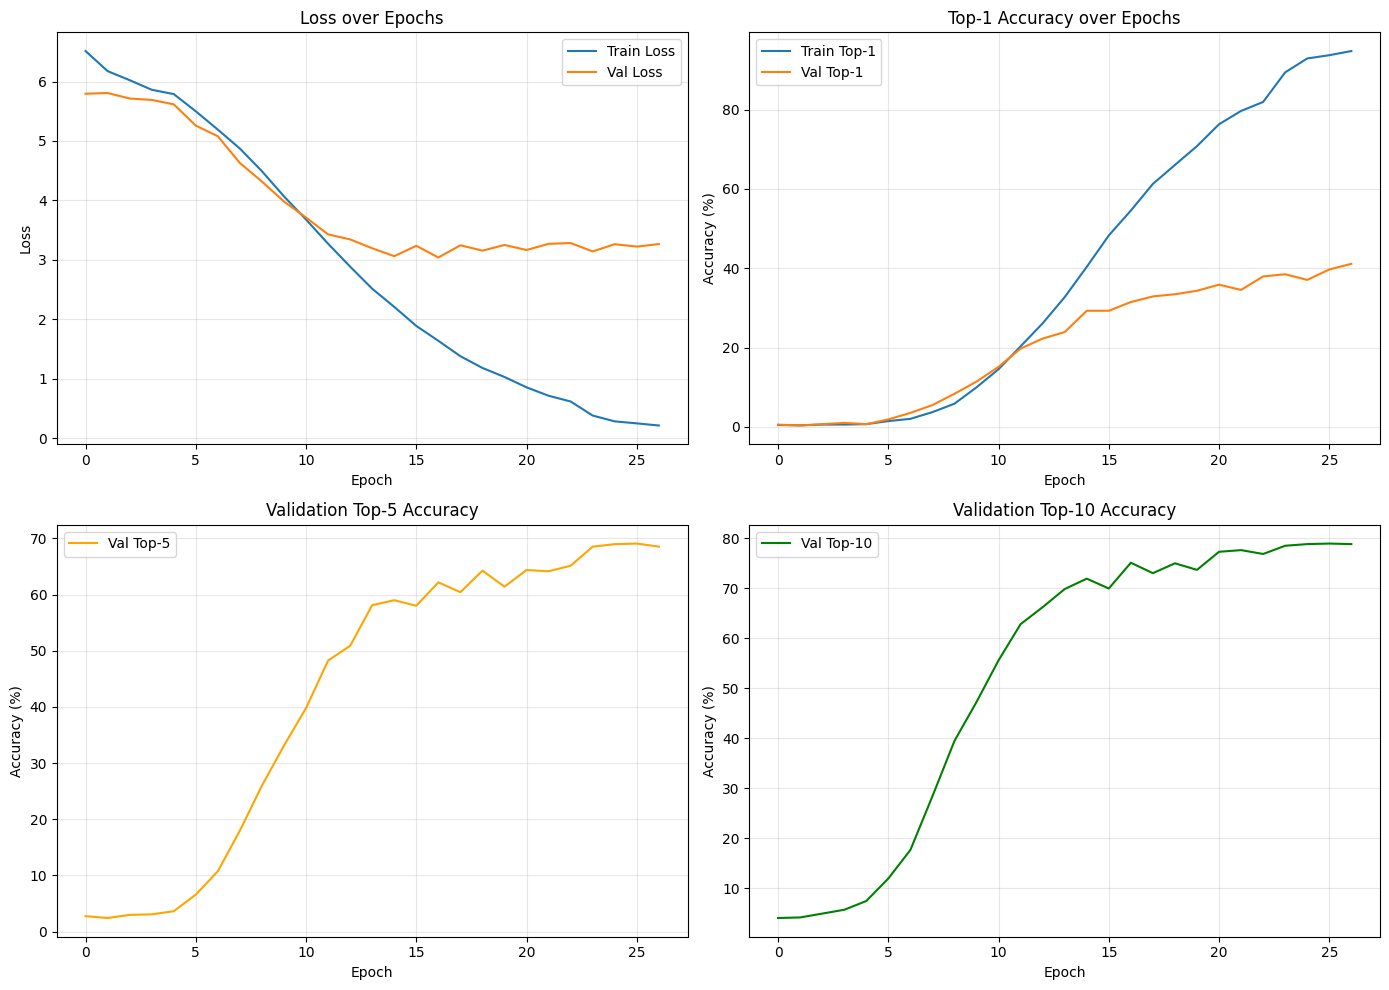

Training history plot saved!


In [9]:
# Plot training history
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(history['train_loss'], label='Train Loss')
axes[0, 0].plot(history['val_loss'], label='Val Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Loss over Epochs')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(history['train_acc'], label='Train Top-1')
axes[0, 1].plot(history['val_acc'], label='Val Top-1')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy (%)')
axes[0, 1].set_title('Top-1 Accuracy over Epochs')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(history['val_top5'], label='Val Top-5', color='orange')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Accuracy (%)')
axes[1, 0].set_title('Validation Top-5 Accuracy')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(history['val_top10'], label='Val Top-10', color='green')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy (%)')
axes[1, 1].set_title('Validation Top-10 Accuracy')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print("Training history plot saved!")

## 8. Test Set Evaluation

In [10]:
# Create test loader only when needed (using preprocessed .npy files)
loaders = get_data_loaders(
    manifest_path=MANIFEST_PATH,
    num_classes=Config.NUM_CLASSES,
    batch_size=Config.BATCH_SIZE,
    num_workers=0,
    pin_memory_train=False,
    pin_memory_eval=False,
    include_train_val=False,
    include_test=True
)

test_loader = loaders['test']

# Load best model
checkpoint = torch.load(f'{Config.CHECKPOINT_DIR}/best_model.pth')
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

#print(f"Loaded best model from epoch {checkpoint['epoch']} "
#      f"(Val Top-1: {checkpoint['val_acc']:.2f}%)")

# Evaluate on test set
test_top1 = 0.0
test_top5 = 0.0
test_top10 = 0.0

all_preds = []
all_labels = []
inference_times = []

with torch.no_grad():
    for frames, labels, _ in test_loader:
        frames = frames.to(device)
        labels = labels.to(device)
        
        # Measure inference time
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        start = time.time()
        
        outputs = model(frames)
        
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        end = time.time()
        
        batch_time = (end - start) / frames.size(0)
        inference_times.append(batch_time)
        
        # Metrics
        acc1, acc5, acc10 = accuracy(outputs, labels, topk=(1, 5, 10))
        test_top1 += acc1.item()
        test_top5 += acc5.item()
        test_top10 += acc10.item()
        
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


test_top1 /= len(test_loader)
test_top5 /= len(test_loader)
test_top10 /= len(test_loader)
avg_inference_time = np.mean(inference_times) * 1000

# Per-class accuracy
class_correct = defaultdict(int)
class_total = defaultdict(int)
for pred, label in zip(all_preds, all_labels):
    class_correct[label] += int(pred == label)
    class_total[label] += 1

results = {
    'test_top1': test_top1,
    'test_top5': test_top5,
    'test_top10': test_top10,
    'avg_inference_time_ms': avg_inference_time,
    'best_epoch': checkpoint['epoch'],
    'best_val_loss': best_val_loss,
}

WLASL test: 668 samples loaded

Data loaders created (from preprocessed .npy files):
  Test batches: 42


In [11]:
# CPU Speed Test for Edge Deployment
print("\n" + "=" * 60)
print("CPU INFERENCE SPEED TEST (Edge Deployment Simulation)")
print("=" * 60)

class Trainer:
    def __init__(self, model):
        self.model = model
    
    def evaluate_cpu_speed(self, dataloader, num_runs=100):
        self.model.eval()
        self.model = self.model.cpu()
        
        # Get a sample input
        sample_input = None
        for frames, _, _ in dataloader:
            sample_input = frames[:1].cpu()
            break
        
        if sample_input is None:
            return {'avg_ms': 0.0, 'std_ms': 0.0}
        
        # Warmup
        with torch.no_grad():
            for _ in range(10):
                _ = self.model(sample_input)
        
        # Benchmark
        times = []
        for _ in range(num_runs):
            start = time.time()
            with torch.no_grad():
                _ = self.model(sample_input)
            end = time.time()
            times.append((end - start) * 1000)
        
        return {
            'avg_ms': np.mean(times),
            'std_ms': np.std(times)
        }

trainer = Trainer(model)
results_cpu = trainer.evaluate_cpu_speed(loaders['test'], num_runs=100)

print(f"\nCPU Inference: {results_cpu['avg_ms']:.2f} ± {results_cpu['std_ms']:.2f} ms")
print(f"CPU Throughput: {1000/results_cpu['avg_ms']:.1f} videos/sec")

# Also update saved results with CPU metrics
results['cpu_inference_ms'] = results_cpu['avg_ms']
results['cpu_throughput'] = 1000 / results_cpu['avg_ms']
with open('test_results.json', 'w') as f:
    json.dump({k: float(v) if isinstance(v, (np.floating, np.integer)) else v 
               for k, v in results.items()}, f, indent=2)
print("Updated results with CPU metrics")


CPU INFERENCE SPEED TEST (Edge Deployment Simulation)

CPU Inference: 161.00 ± 6.02 ms
CPU Throughput: 6.2 videos/sec
Updated results with CPU metrics


## 9. Confusion Matrix and Analysis

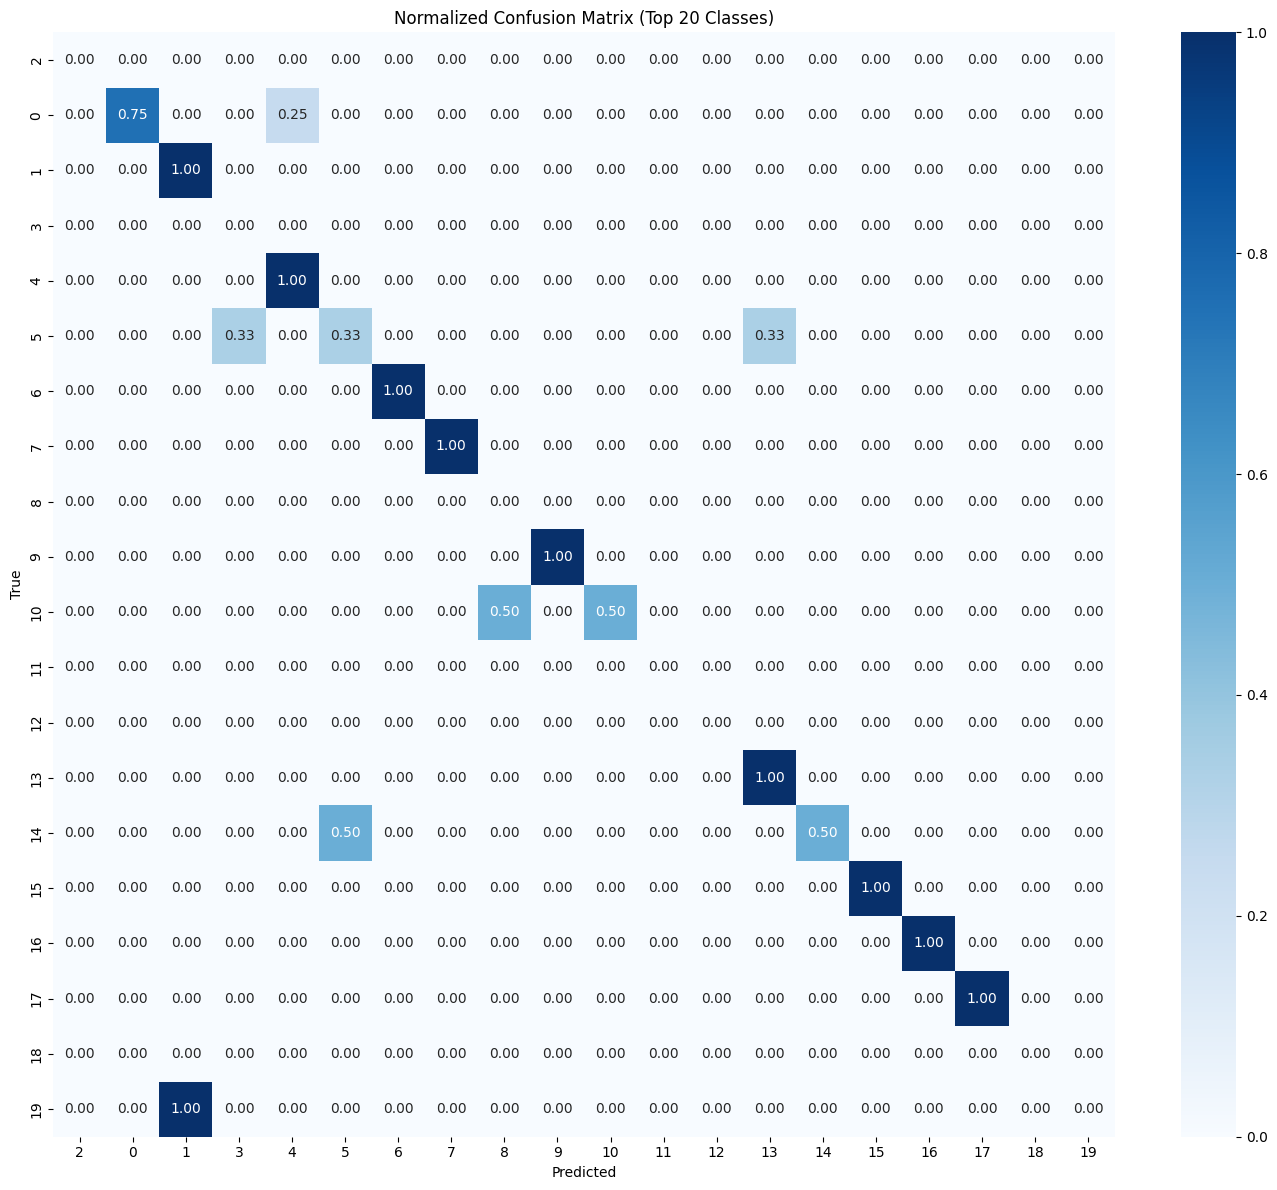

Confusion matrix saved!

Top 10 most confused pairs:
  True: 0, Pred: 4, Count: 1
  True: 5, Pred: 3, Count: 1
  True: 5, Pred: 13, Count: 1
  True: 10, Pred: 8, Count: 1
  True: 14, Pred: 5, Count: 1
  True: 19, Pred: 1, Count: 1


In [15]:
# Plot confusion matrix for top 20 classes
from sklearn.metrics import confusion_matrix

class_counts = Counter(all_labels)
top_20_classes = [c for c, _ in class_counts.most_common(20)]

mask = np.isin(all_labels, top_20_classes)
y_true_subset = np.array(all_labels)[mask]
y_pred_subset = np.array(all_preds)[mask]

cm = confusion_matrix(y_true_subset, y_pred_subset, labels=top_20_classes)
row_sums = cm.sum(axis=1)[:, np.newaxis]
row_sums = np.where(row_sums == 0, 1, row_sums)  # avoid division by zero
cm_normalized = cm.astype('float') / row_sums

plt.figure(figsize=(14, 12))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=top_20_classes, yticklabels=top_20_classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Normalized Confusion Matrix (Top 20 Classes)')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrix saved!")

# Identify most confused class pairs
confusions = []
for i in range(len(top_20_classes)):
    for j in range(len(top_20_classes)):
        if i != j and cm[i, j] > 0:
            confusions.append((top_20_classes[i], top_20_classes[j], cm[i, j]))

confusions.sort(key=lambda x: x[2], reverse=True)
print("\nTop 10 most confused pairs:")
for true_class, pred_class, count in confusions[:10]:
    print(f"  True: {true_class}, Pred: {pred_class}, Count: {count}")

## 10. Failure Case Analysis

In [13]:
# Analyze failure cases
failures = [(i, true, pred) for i, (true, pred) in enumerate(zip(all_labels, all_preds)) if true != pred]
print(f"Total failures: {len(failures)} out of {len(all_labels)} ({len(failures)/len(all_labels)*100:.1f}%)")

# Most commonly misclassified classes
misclassified_counts = Counter([true for _, true, _ in failures])
print("\nMost commonly misclassified classes:")
for class_idx, count in misclassified_counts.most_common(10):
    class_name = top_300[class_idx][0] if class_idx < len(top_300) else f"Class_{class_idx}"
    total = class_counts[class_idx]
    print(f"  {class_name}: {count}/{total} misclassified ({count/total*100:.1f}%)")

# Most common wrong predictions
wrong_pred_counts = Counter([pred for _, _, pred in failures])
print("\nMost common wrong predictions:")
for class_idx, count in wrong_pred_counts.most_common(10):
    class_name = top_300[class_idx][0] if class_idx < len(top_300) else f"Class_{class_idx}"
    print(f"  {class_name}: predicted {count} times incorrectly")

Total failures: 482 out of 668 (72.2%)

Most commonly misclassified classes:
  computer: 5/5 misclassified (100.0%)
  before: 4/4 misclassified (100.0%)
  drink: 3/4 misclassified (75.0%)
  candy: 3/3 misclassified (100.0%)
  fine: 3/3 misclassified (100.0%)
  help: 3/3 misclassified (100.0%)
  all: 3/3 misclassified (100.0%)
  black: 3/3 misclassified (100.0%)
  cool: 3/3 misclassified (100.0%)
  finish: 3/3 misclassified (100.0%)

Most common wrong predictions:
  yes: predicted 10 times incorrectly
  woman: predicted 9 times incorrectly
  dog: predicted 8 times incorrectly
  need: predicted 8 times incorrectly
  know: predicted 8 times incorrectly
  many: predicted 8 times incorrectly
  play: predicted 8 times incorrectly
  banana: predicted 7 times incorrectly
  blue: predicted 6 times incorrectly
  bathroom: predicted 5 times incorrectly


## 11. Export Model for Edge Deployment

In [14]:
# Export to TorchScript for deployment
model.eval()

# Trace the model
# Note: For CPU export, ensure model is on CPU before tracing
model = model.to(device)
example_input = torch.randn(1, 3, Config.NUM_FRAMES, Config.FRAME_SIZE, Config.FRAME_SIZE).to(device)

try:
    traced_model = torch.jit.trace(model, example_input)
    traced_model.save('mobilenetv3_mamba_wlasl300.pt')
    print("Model exported to TorchScript: mobilenetv3_mamba_wlasl300.pt")
    
    # Verify
    loaded_model = torch.jit.load('mobilenetv3_mamba_wlasl300.pt')
    with torch.no_grad():
        output = loaded_model(example_input)
    print(f"Verification successful! Output shape: {output.shape}")
except Exception as e:
    print(f"TorchScript export failed: {e}")
    print("Saving state dict instead...")
    torch.save(model.state_dict(), 'mobilenetv3_mamba_wlasl300_state_dict.pth')
    print("State dict saved: mobilenetv3_mamba_wlasl300_state_dict.pth")

# Print final summary
print("\n" + "=" * 60)
print("FINAL SUMMARY")
print("=" * 60)
print(f"Model: MobileNetV3-Large + {Config.N_MAMBA_LAYERS}-layer Mamba")
print(f"Dataset: WLASL{Config.NUM_CLASSES} (dual-source fallback loading)")
print(f"Input: {Config.NUM_FRAMES} frames × {Config.FRAME_SIZE}×{Config.FRAME_SIZE} RGB")
print(f"Parameters: {total_params:,}")
print(f"Model Size: {total_params * 4 / (1024**2):.2f} MB")
print(f"Test Top-1: {test_top1:.2f}%")
print(f"Test Top-5: {test_top5:.2f}%")
print(f"Test Top-10: {test_top10:.2f}%")
print(f"GPU Inference: {avg_inference_time:.2f} ms/video")
print(f"CPU Inference: {results_cpu['avg_ms']:.2f} ± {results_cpu['std_ms']:.2f} ms/video")
print("=" * 60)

Model exported to TorchScript: mobilenetv3_mamba_wlasl300.pt
Verification successful! Output shape: torch.Size([1, 300])

FINAL SUMMARY
Model: MobileNetV3-Large + 2-layer Mamba
Dataset: WLASL300 (dual-source fallback loading)
Input: 16 frames × 224×224 RGB
Parameters: 4,141,404
Model Size: 15.80 MB
Test Top-1: 27.83%
Test Top-5: 58.98%
Test Top-10: 72.27%
GPU Inference: 10.10 ms/video
CPU Inference: 161.00 ± 6.02 ms/video


In [16]:
import tarfile
from IPython.display import FileLink
# Create a tar.gz archive of the saved models
with tarfile.open("output_files.tar.gz", "w:gz") as tar:
    tar.add("/kaggle/working/", arcname="models")
# Generate download link for the archive
FileLink("output_files.tar.gz")

/kaggle/working/output_files.tar.gz